# 5. Regression

Target: `ComAvgPlaytime_log`, the log-transformed community playtime. We start
from interpretable linear baselines (simple and multiple) and then evaluate
two non-linear regressors (KNN and Decision Tree). 70/30 hold-out split;
metrics: R², MSE, MAE.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

df = pd.read_csv("../data/df_clean2.2.csv")
y = df["ComAvgPlaytime_log"]

def evaluate(model, X_tr, X_te, y_tr, y_te):
    pred = model.fit(X_tr, y_tr).predict(X_te)
    return (r2_score(y_te, pred), mean_squared_error(y_te, pred),
            mean_absolute_error(y_te, pred))

results = {}

## 5.1 Simple linear regression

Single predictor: `AvgGameweight`, the feature most correlated with playtime.

R2 = 0.481, MSE = 0.391, MAE = 0.475
intercept = 2.206, slope = 0.764


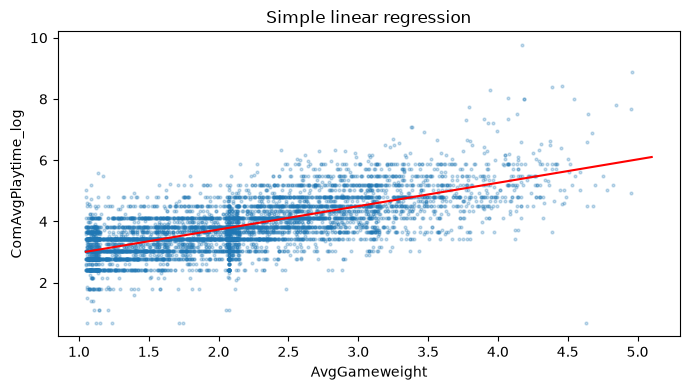

In [2]:
X1 = df[["AvgGameweight"]]
X1_tr, X1_te, y_tr, y_te = train_test_split(X1, y, test_size=0.3, random_state=42)

slr = LinearRegression()
results["Simple Linear Regression"] = evaluate(slr, X1_tr, X1_te, y_tr, y_te)
print("R2 = %.3f, MSE = %.3f, MAE = %.3f" % results["Simple Linear Regression"])
print(f"intercept = {slr.intercept_:.3f}, slope = {slr.coef_[0]:.3f}")

plt.figure(figsize=(7, 4))
plt.scatter(X1_te, y_te, s=4, alpha=.25)
xs = np.linspace(X1.min().item(), X1.max().item(), 50).reshape(-1, 1)
plt.plot(xs, slr.predict(pd.DataFrame(xs, columns=["AvgGameweight"])), "r")
plt.xlabel("AvgGameweight")
plt.ylabel("ComAvgPlaytime_log")
plt.title("Simple linear regression")
plt.tight_layout()
plt.show()

Complexity alone explains roughly half of the variability of the
log-playtime; the dispersion (and a hint of curvature) shows the rest is
driven by other factors. A Lasso on the same predictor is also tried as a
regularized alternative: with the default penalty it shrinks the single
coefficient to zero and explains no variance, so it is not retained.

In [3]:
lasso_r2, lasso_mse, lasso_mae = evaluate(Lasso(), X1_tr, X1_te, y_tr, y_te)
print(f"Lasso: R2 = {lasso_r2:.3f}, MSE = {lasso_mse:.3f}, MAE = {lasso_mae:.3f}")

Lasso: R2 = -0.000, MSE = 0.753, MAE = 0.668


## 5.2 Multiple linear regression

Adding `ComAgeRec` to the predictor set.

R2 = 0.532, MSE = 0.353, MAE = 0.450


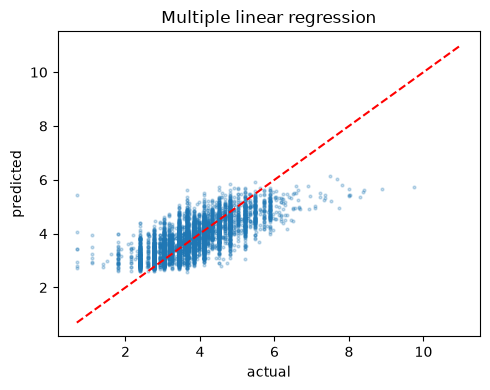

In [4]:
X2 = df[["AvgGameweight", "ComAgeRec"]]
X2_tr, X2_te, y_tr, y_te = train_test_split(X2, y, test_size=0.3, random_state=42)

mlr = LinearRegression()
results["Multiple Linear Regression"] = evaluate(mlr, X2_tr, X2_te, y_tr, y_te)
print("R2 = %.3f, MSE = %.3f, MAE = %.3f" % results["Multiple Linear Regression"])

pred = mlr.predict(X2_te)
plt.figure(figsize=(5, 4))
plt.scatter(y_te, pred, s=4, alpha=.25)
lims = [y.min(), y.max()]
plt.plot(lims, lims, "r--")
plt.xlabel("actual")
plt.ylabel("predicted")
plt.title("Multiple linear regression")
plt.tight_layout()
plt.show()

The community age recommendation adds information beyond complexity: R²
increases and both errors decrease.

## 5.3 Non-linear models

Feature set extended to `AvgGameweight`, `ComAgeRec`, `PopularityScore`,
`MinPlayers`, `MaxPlayers`.

In [5]:
X5 = df[["AvgGameweight", "ComAgeRec", "PopularityScore", "MinPlayers", "MaxPlayers"]]
X5_tr, X5_te, y_tr, y_te = train_test_split(X5, y, test_size=0.3, random_state=42)
scaler = StandardScaler().fit(X5_tr)
X5_tr_s, X5_te_s = scaler.transform(X5_tr), scaler.transform(X5_te)

### KNN regression

Distance-based, hence the standardization. Starting from the sqrt(N) baseline
we scan k and the weighting scheme.

In [6]:
k_base = int(np.sqrt(len(X5)))
print("baseline k =", k_base, "-> R2 = %.3f, MSE = %.3f, MAE = %.3f" %
      evaluate(KNeighborsRegressor(k_base), X5_tr_s, X5_te_s, y_tr, y_te))

rows = [[k, w, *evaluate(KNeighborsRegressor(k, weights=w),
                         X5_tr_s, X5_te_s, y_tr, y_te)]
        for k in [10, 20, 30, 42, 60, 100] for w in ["uniform", "distance"]]
knn_scan = pd.DataFrame(rows, columns=["k", "weights", "R2", "MSE", "MAE"]).round(3)
knn_scan.sort_values("R2", ascending=False).head(6)

baseline k = 148 -> R2 = 0.549, MSE = 0.340, MAE = 0.438


,k,weights,R2,MSE,MAE
9,60,distance,0.557,0.334,0.433
7,42,distance,0.556,0.334,0.433
11,100,distance,0.556,0.334,0.434
5,30,distance,0.554,0.336,0.435
6,42,uniform,0.554,0.336,0.434
8,60,uniform,0.554,0.336,0.435


In [7]:
knn_best = KNeighborsRegressor(42)
results["KNN (k=42)"] = evaluate(knn_best, X5_tr_s, X5_te_s, y_tr, y_te)
print("R2 = %.3f, MSE = %.3f, MAE = %.3f" % results["KNN (k=42)"])

R2 = 0.554, MSE = 0.336, MAE = 0.434


### Decision Tree regressor

The default tree overfits badly, so we pre-prune via randomized search and
then check cost-complexity pruning on the tuned configuration.

In [8]:
dt_full = DecisionTreeRegressor(random_state=42).fit(X5_tr, y_tr)
print(f"default tree: train R2 = {dt_full.score(X5_tr, y_tr):.3f}, "
      f"test R2 = {dt_full.score(X5_te, y_te):.3f}")

param_dist = {"criterion": ["squared_error", "friedman_mse"],
              "max_depth": [4, 6, 8, 10, 12],
              "min_samples_split": [2, 20, 50, 100],
              "min_samples_leaf": [1, 10, 30, 50, 100]}
search = RandomizedSearchCV(DecisionTreeRegressor(random_state=42), param_dist,
                            n_iter=60, cv=5, random_state=42, n_jobs=-1)
search.fit(X5_tr, y_tr)
search.best_params_

default tree: train R2 = 1.000, test R2 = 0.160


/Users/jacopograndi/Desktop/data mining/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:489: FitFailedWarning: 
145 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
56 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/jacopograndi/Desktop/data mining/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jacopograndi/Desktop/data mining/.venv/lib/python3.14/site-packages/sklearn/base.py", line 1393, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  Fil

{'min_samples_split': 2,
 'min_samples_leaf': 100,
 'max_depth': 8,
 'criterion': 'squared_error'}

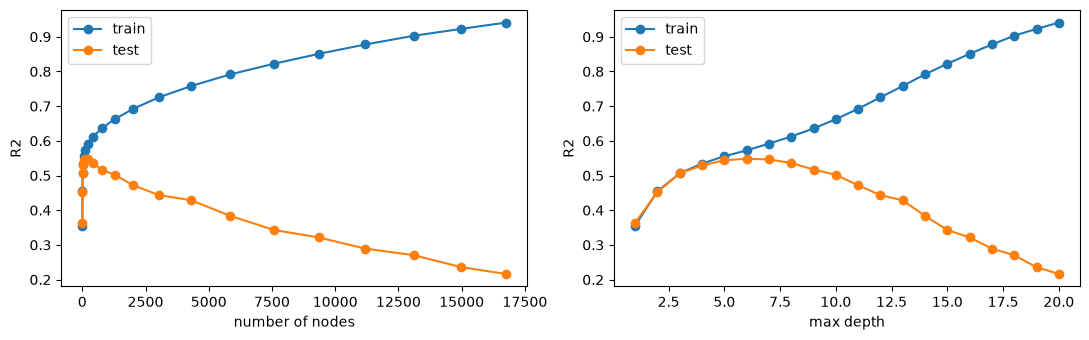

In [9]:
# complexity analysis: how depth (and the resulting number of nodes) drives
# the train/test gap
depths = range(1, 21)
train_r2, test_r2, n_nodes = [], [], []
for d in depths:
    t = DecisionTreeRegressor(max_depth=d, random_state=42).fit(X5_tr, y_tr)
    train_r2.append(t.score(X5_tr, y_tr))
    test_r2.append(t.score(X5_te, y_te))
    n_nodes.append(t.tree_.node_count)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(n_nodes, train_r2, "o-", label="train")
axes[0].plot(n_nodes, test_r2, "o-", label="test")
axes[0].set(xlabel="number of nodes", ylabel="R2")
axes[1].plot(depths, train_r2, "o-", label="train")
axes[1].plot(depths, test_r2, "o-", label="test")
axes[1].set(xlabel="max depth", ylabel="R2")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

Test R² peaks around depth 5-6 and then declines while the train score keeps
growing: the classic overfitting picture. Cost-complexity pruning on the tuned
tree gives a final check on the effective size.

In [10]:
dt_tuned = search.best_estimator_
path = dt_tuned.cost_complexity_pruning_path(X5_tr, y_tr)
rows = [[a, DecisionTreeRegressor(**search.best_params_, ccp_alpha=a,
                                  random_state=42)
         .fit(X5_tr, y_tr).score(X5_te, y_te)]
        for a in np.unique(path.ccp_alphas)[::10]]
ccp = pd.DataFrame(rows, columns=["ccp_alpha", "test R2"])
best_alpha = ccp.loc[ccp["test R2"].idxmax(), "ccp_alpha"]
print(ccp.round(4).head(6).to_string(index=False), "\nbest alpha:", best_alpha)

dt_final = DecisionTreeRegressor(**search.best_params_, ccp_alpha=best_alpha,
                                 random_state=42)
results["Decision Tree (tuned)"] = evaluate(dt_final, X5_tr, X5_te, y_tr, y_te)
print("R2 = %.3f, MSE = %.3f, MAE = %.3f" % results["Decision Tree (tuned)"])

 ccp_alpha  test R2
    0.0000   0.5572
    0.0001   0.5570
    0.0001   0.5557
    0.0002   0.5535
    0.0003   0.5537
    0.0005   0.5505 
best alpha: 0.0
R2 = 0.557, MSE = 0.334, MAE = 0.435


## 5.4 Performance comparison

In [11]:
pd.DataFrame(results, index=["R2", "MSE", "MAE"]).T.round(3)

,R2,MSE,MAE
Simple Linear Regression,0.481,0.391,0.475
Multiple Linear Regression,0.532,0.353,0.450
KNN (k=42),0.554,0.336,0.434
Decision Tree (tuned),0.557,0.334,0.435


The multiple linear model is the strongest fully interpretable baseline. The
two non-linear models end up practically tied around R² = 0.55, only a few
points above it: the tree needs careful depth control to get there, while KNN
reaches the same level with almost no tuning. All models plateau slightly
above R² = 0.5, so playtime is only partially explained by complexity, age,
popularity and player counts.